# Limpieza de las Criptos

## Importaciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from IPython.display import display
# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

## Carga del Dataset

In [3]:
df_criptos = pd.read_csv('../data/criptoradar_crypto_final.csv')
df_data_raw = df_criptos.copy()
df_criptos

,fecha,crypto_id,open,high,low,close,volume
0,2024-04-24,bitcoin,64616.6600,65142.8600,62800.0000,64137.1100,6.216706e+08
1,2024-04-25,bitcoin,64137.1100,65281.9200,63350.0100,63508.9800,5.849031e+08
2,2024-04-26,bitcoin,63508.9800,64160.6900,62399.3300,62960.3500,5.104126e+08
3,2024-04-27,bitcoin,62960.3500,64367.8900,62751.1600,63542.9100,4.406123e+08
4,2024-04-28,bitcoin,63542.9100,63980.3900,61802.0000,63036.1100,4.514398e+08
...,...,...,...,...,...,...,...
3195,2026-07-01,ripple,1.0608,1.1124,1.0450,1.0933,1.146165e+07
3196,2026-07-02,ripple,1.0933,1.1238,1.0790,1.1201,7.061506e+06
3197,2026-07-03,ripple,1.1201,1.1806,1.1142,1.1723,1.421722e+07
3198,2026-07-04,ripple,1.1723,1.1842,1.1249,1.1370,7.839374e+06


## Radiografia inicial

In [4]:
# Configuración para ver todas las columnas en el notebook
pd.set_option('display.max_columns', None)

In [5]:
# Se realiza un análisis técnico , "data quality check" para analizar el dataset de forma automática y entender su calidad

# Función 1 :radiografía técnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                        {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()


# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 3,200
  • Columnas: 7
  • Celdas totales: 22,400
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 0.47 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
fecha,str,3200,0,0.00%,800,25.00%,2024-04-24
crypto_id,str,3200,0,0.00%,4,0.12%,bitcoin
open,float64,3200,0,0.00%,3163,98.84%,64616.660000
high,float64,3200,0,0.00%,3145,98.28%,65142.860000
low,float64,3200,0,0.00%,3157,98.66%,62800.000000
close,float64,3200,0,0.00%,3164,98.88%,64137.110000
volume,float64,3200,0,0.00%,3200,100.00%,621670568.004095


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
open,3200.0,2.209197e+04,3.777627e+04,4.241600e-01,4.743822e+01,8.777900e+02,1.701919e+04,1.250070e+05
high,3200.0,2.246689e+04,3.838232e+04,4.380500e-01,5.024295e+01,9.142900e+02,1.742569e+04,1.262000e+05
low,3200.0,2.169834e+04,3.714075e+04,3.822000e-01,4.594565e+01,8.191000e+02,1.579762e+04,1.223254e+05
close,3200.0,2.208972e+04,3.777396e+04,4.241600e-01,4.743822e+01,8.777900e+02,1.701919e+04,1.250070e+05
volume,3200.0,2.908488e+08,3.952517e+08,5.063333e+06,6.950031e+07,1.563901e+08,3.379209e+08,8.220814e+09


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


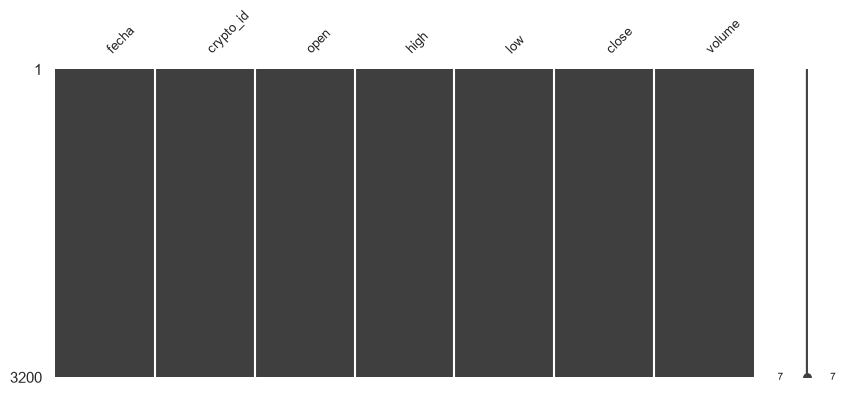


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
------------------------------------------------------------


In [6]:
# Para ver el estado actual:
radiografia_tecnica(df_criptos)

# Para ver qué deberías limpiar:
plan_accion_datos(df_criptos)

## Comprobaciones tras la radiografia

Consultamos la información del dataframe para saber que columnas tiene.

In [7]:
df_criptos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      3200 non-null   str    
 1   crypto_id  3200 non-null   str    
 2   open       3200 non-null   float64
 3   high       3200 non-null   float64
 4   low        3200 non-null   float64
 5   close      3200 non-null   float64
 6   volume     3200 non-null   float64
dtypes: float64(5), str(2)
memory usage: 175.1 KB


Por si acaso aunque en la función anterior comprobamos que no hay nulos y duplicados, comprobamos si hay.

In [8]:
df_criptos.isnull().sum()

fecha        0
crypto_id    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

In [9]:
df_criptos.duplicated().sum()

np.int64(0)

## Cambiar el formato de la fecha al correcto

In [10]:
df_criptos['fecha'] = pd.to_datetime(df_criptos['fecha'])

In [11]:
df_criptos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fecha      3200 non-null   datetime64[us]
 1   crypto_id  3200 non-null   str           
 2   open       3200 non-null   float64       
 3   high       3200 non-null   float64       
 4   low        3200 non-null   float64       
 5   close      3200 non-null   float64       
 6   volume     3200 non-null   float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 175.1 KB


## Renombrar columna fecha

In [13]:
df_criptos.rename(columns={'fecha': 'datetime'}, inplace=True)

In [15]:
df_criptos

,datetime,crypto_id,open,high,low,close,volume
0,2024-04-24,bitcoin,64616.6600,65142.8600,62800.0000,64137.1100,6.216706e+08
1,2024-04-25,bitcoin,64137.1100,65281.9200,63350.0100,63508.9800,5.849031e+08
2,2024-04-26,bitcoin,63508.9800,64160.6900,62399.3300,62960.3500,5.104126e+08
3,2024-04-27,bitcoin,62960.3500,64367.8900,62751.1600,63542.9100,4.406123e+08
4,2024-04-28,bitcoin,63542.9100,63980.3900,61802.0000,63036.1100,4.514398e+08
...,...,...,...,...,...,...,...
3195,2026-07-01,ripple,1.0608,1.1124,1.0450,1.0933,1.146165e+07
3196,2026-07-02,ripple,1.0933,1.1238,1.0790,1.1201,7.061506e+06
3197,2026-07-03,ripple,1.1201,1.1806,1.1142,1.1723,1.421722e+07
3198,2026-07-04,ripple,1.1723,1.1842,1.1249,1.1370,7.839374e+06


## Comparación de DatasetInicial con final

In [16]:
comparativo_snapshot(df_data_raw, df_criptos)

             ⚖️ COMPARATIVA DE CALIDAD DE DATOS             


Métrica,Snapshot Inicial,Snapshot Final
Filas Totales,"3,200","3,200"
Columnas,7,7
Celdas con Nulos,0,0
% Global de Nulos,0.00%,0.00%
Filas Duplicadas,0,0
Memoria (MB),0.47,0.32



✅ Se han depurado 0 filas en total.


## Creación del Dataset Limpio

In [19]:
#Creamos el dataset final, que será el que se use para el análisis de datos y la visualización de los mismos.
df_criptos.to_csv('../data/criptoradar_crypto_final_clean.csv', index=False)